# AFOLU fix pipeline — single consolidated notebook

Diagnoses and applies every AFOLU-related fix in one place, then refreshes the Tableau database.

## Fixes covered

| # | Fix | Layer | Subsectors affected |
|---|---|---|---|
| 1 | Cropland Markov 2018 anomaly (`pij_lndu_*_to_croplands` collapsed in 2018 with mass redirected to shrublands) | Input CSV | 3.B.2 Cropland, 3.B.3 Grassland |
| 2 | Wetlands Markov absorbing-state (broken row `pij_lndu_wetlands_to_*`, fixed by setting diagonal = 1 and incoming = 0) | Input CSV | 3.B.4 Wetlands |
| 3 | Livestock-population step-down at 2023 (artificial drop in `pop_lvst_initial_*` from 2022→2023, then held flat) | Input CSV | 3.A.1 Enteric Fermentation, 3.A.2 Manure Management, 3.C.6 Indirect N2O Manure |
| 4 | Postprocessing zero-patch propagation (rescaler patched zero-vars only at `time_period_ref`, collapsing 2019+ to 0 via −100% pct_diff) | Python module | 3.B.5 Settlements, 3.B.6 Other land, 3.B.4 Wetlands, 3.B.3 Grassland, 3.C.6 |

## Toggles

- `APPLY_INPUT_FIXES`: write fixes 1, 2, 3 to the active input CSV (with backup). After applying input fixes, **re-run SISEPUEDE** from `workflow/morocco_manager_wb.ipynb` so the new outputs reflect them.
- `REFRESH_DB`: re-run intertemporal decomposition + tableau postprocessing on the latest model output. Always safe to run.

Each section is idempotent — if a fix is already applied, the cell detects it and skips writing.

In [8]:
# === Setup ===
import sys, shutil
from pathlib import Path
from datetime import datetime
import pandas as pd, numpy as np, yaml
import matplotlib.pyplot as plt

NB_DIR       = Path.cwd()
NOTEBOOKS    = NB_DIR.parent
REPO_ROOT    = NOTEBOOKS.parent           # ssp_modeling/
PROJECT_ROOT = REPO_ROOT.parent
INPUT_DIR    = REPO_ROOT / 'input_data'
CONFIG_PATH  = NOTEBOOKS / 'config_files' / 'config.yaml'

for p in (PROJECT_ROOT, NOTEBOOKS):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

ACTIVE_CSV = INPUT_DIR / cfg['ssp_input_file_name']
REGION     = cfg['country_name']
ISO_CODE3  = cfg['country_code']
YEAR_REF   = 2018

run_dirs   = sorted((REPO_ROOT / 'ssp_run_output').glob('sisepuede_results_sisepuede_run_*'))
LATEST_RUN = run_dirs[-1] if run_dirs else None

print(f'Active input  : {ACTIVE_CSV.name}')
print(f'Latest run    : {LATEST_RUN.name if LATEST_RUN else "<none>"}')
print()

# === Master toggles ===
APPLY_INPUT_FIXES = False    # writes the patched input CSV (with .bak backup)
REFRESH_DB        = True     # always safe — regenerates decomposed + tableau CSVs
print(f'APPLY_INPUT_FIXES = {APPLY_INPUT_FIXES}')
print(f'REFRESH_DB        = {REFRESH_DB}')

Active input  : sisepuede_raw_inputs_recalibrated_electricity_trns_improved_cement.csv
Latest run    : sisepuede_results_sisepuede_run_2026-05-20T16;07;55.383771

APPLY_INPUT_FIXES = False
REFRESH_DB        = True


## 1) Diagnose current state of each fix

In [9]:
df_inp = pd.read_csv(ACTIVE_CSV)
all_pij = [c for c in df_inp.columns if c.startswith('pij_lndu_')]
from_states = sorted({c.replace('pij_lndu_', '').split('_to_')[0] for c in all_pij})

# --- Fix 1: Cropland 2018 Markov ---
pij_to_crop_2018 = df_inp.loc[df_inp['year']==2018,
    [c for c in df_inp.columns if c.startswith('pij_lndu_') and c.endswith('_to_croplands')]].iloc[0]
skip = {'pij_lndu_croplands_to_croplands','pij_lndu_forests_mangroves_to_croplands',
        'pij_lndu_wetlands_to_croplands','pij_lndu_settlements_to_croplands'}
fix1_ok = pij_to_crop_2018.drop([c for c in skip if c in pij_to_crop_2018.index]).sum() > 0.01

# --- Fix 2: Wetlands absorbing-state ---
wet_diag = df_inp.loc[df_inp['year']==2018, 'pij_lndu_wetlands_to_wetlands'].iloc[0]
fix2_ok  = abs(wet_diag - 1.0) < 1e-6

# --- Fix 3: Livestock 2022 flat through 2050 ---
INIT_COLS = sorted([c for c in df_inp.columns if c.startswith('pop_lvst_initial_')])
row_2022  = df_inp.loc[df_inp['year']==2022, INIT_COLS].iloc[0]
row_2023  = df_inp.loc[df_inp['year']==2023, INIT_COLS].iloc[0]
row_2050  = df_inp.loc[df_inp['year']==2050, INIT_COLS].iloc[0]
fix3_ok   = np.isclose(row_2023, row_2022, rtol=1e-4).all() and np.isclose(row_2050, row_2022, rtol=1e-4).all()

# --- Fix 4: Postprocessing module ---
decomp_py = REPO_ROOT / 'output_postprocessing' / 'intertemporal_decomposition.py'
py_src    = decomp_py.read_text()
fix4_ok   = 'across all years for primary_ids' in py_src

def mark(b): return '✅ already applied' if b else '⚠️  not applied'
print(f'1. Cropland Markov 2018           : {mark(fix1_ok)}')
print(f'2. Wetlands Markov absorbing      : {mark(fix2_ok)}')
print(f'3. Livestock pop_lvst flat 2022+  : {mark(fix3_ok)}')
print(f'4. Postprocessing zero-patch fix  : {mark(fix4_ok)}')

STATE = dict(fix1=fix1_ok, fix2=fix2_ok, fix3=fix3_ok, fix4=fix4_ok)

1. Cropland Markov 2018           : ✅ already applied
2. Wetlands Markov absorbing      : ✅ already applied
3. Livestock pop_lvst flat 2022+  : ✅ already applied
4. Postprocessing zero-patch fix  : ✅ already applied


## 2) Apply input-CSV fixes (1, 2, 3)

Single backup is taken before all three fixes are written. Skip-noop if a fix is already in place.

In [10]:
if APPLY_INPUT_FIXES and not all([STATE['fix1'], STATE['fix2'], STATE['fix3']]):
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    backup = ACTIVE_CSV.with_suffix(f'.csv.bak_{ts}')
    shutil.copy2(ACTIVE_CSV, backup)
    print(f'Backup created: {backup.name}\n')
    df_fixed = df_inp.copy()

    # --- 2a) Cropland Markov 2018 = mean(2017, 2019), then renormalize rows ---
    if not STATE['fix1']:
        row_2017 = df_fixed.loc[df_fixed['year']==2017, all_pij].iloc[0]
        row_2019 = df_fixed.loc[df_fixed['year']==2019, all_pij].iloc[0]
        row_new  = (row_2017 + row_2019) / 2.0
        for s in from_states:
            cols = [c for c in all_pij if c.startswith(f'pij_lndu_{s}_to_')]
            rs = row_new[cols].sum()
            if rs > 0:
                row_new[cols] = row_new[cols] / rs
        df_fixed.loc[df_fixed['year']==2018, all_pij] = row_new[all_pij].values
        print('  Fix 1 applied — replaced 2018 Markov row with mean(2017, 2019) renormalized.')
    else:
        print('  Fix 1 skipped (already applied).')

    # --- 2b) Wetlands absorbing state: diag=1, all incoming=0 ---
    if not STATE['fix2']:
        wet_diag_col = 'pij_lndu_wetlands_to_wetlands'
        wet_to_cols  = [c for c in df_fixed.columns if c.startswith('pij_lndu_') and c.endswith('_to_wetlands')]
        for c in wet_to_cols:
            df_fixed[c] = 0.0
        df_fixed[wet_diag_col] = 1.0
        print('  Fix 2 applied — wetlands diagonal = 1.0, all incoming to wetlands = 0.')
    else:
        print('  Fix 2 skipped (already applied).')

    # --- 2c) Livestock pop_lvst_initial_* held flat at 2022 through 2050 ---
    if not STATE['fix3']:
        anchor = df_fixed.loc[df_fixed['year']==2022, INIT_COLS].iloc[0]
        mask   = df_fixed['year'].isin(range(2023, 2051))
        for c in INIT_COLS:
            df_fixed.loc[mask, c] = anchor[c]
        print('  Fix 3 applied — pop_lvst_initial_* held flat at 2022 value through 2050.')
    else:
        print('  Fix 3 skipped (already applied).')

    df_fixed.to_csv(ACTIVE_CSV, index=False)
    print(f'\nWrote {ACTIVE_CSV.name}')
    print('\n*** RE-RUN SISEPUEDE now (workflow/morocco_manager_wb.ipynb) so model outputs reflect these fixes. ***')
elif APPLY_INPUT_FIXES:
    print('All input fixes already applied — no write needed.')
else:
    print('APPLY_INPUT_FIXES=False — diagnosis only. Set True above to write.')

APPLY_INPUT_FIXES=False — diagnosis only. Set True above to write.


## 3) Postprocessing module check (fix 4)

Fix 4 lives in `output_postprocessing/intertemporal_decomposition.py`. It modifies how the rescaler patches zero-value variables (extends the patch across all years instead of only at the reference year). If the diagnose above showed it's missing, edit that file or restore it from git.

In [11]:
if not STATE['fix4']:
    print('⚠️  Postprocessing fix is missing in intertemporal_decomposition.py')
    print('    Run: git diff ssp_modeling/output_postprocessing/intertemporal_decomposition.py')
    print('    The patched preprocessor should propagate 0.01 to all years where var==0,')
    print('    not just at time_period_ref. Look for the print statement containing the phrase')
    print('    "across all years for primary_ids" — that confirms the fix is in place.')
else:
    print('Postprocessing module fix is in place.')

Postprocessing module fix is in place.


## 4) Refresh the database (decomposition + Tableau CSVs)

Always safe to run. Regenerates `decomposed_ssp_output.csv` from the latest WIDE model output, then regenerates the Tableau-ready CSVs in `ssp_modeling/tableau/data/`.

If you just applied the input fixes above, re-run SISEPUEDE first so this step picks up the new model output.

In [12]:
if REFRESH_DB and LATEST_RUN is not None:
    from ssp_modeling.output_postprocessing.intertemporal_decomposition import run_postprocessing
    from shared_scripts.tableau_postprocessing import run_tableau_postprocessing

    wide_path    = next(LATEST_RUN.glob('*_WIDE_INPUTS_OUTPUTS.csv'))
    targets_path = REPO_ROOT / 'output_postprocessing' / 'data' / 'invent' / f'emission_targets_{ISO_CODE3.lower()}_{YEAR_REF}.csv'
    decomp_out   = LATEST_RUN / 'decomposed_ssp_output.csv'

    # Backup previous decomposed output
    if decomp_out.exists():
        ts = datetime.now().strftime('%Y%m%d_%H%M%S')
        shutil.copy2(decomp_out, decomp_out.with_suffix(f'.csv.bak_{ts}'))
        print(f'Backed up {decomp_out.name} → .bak_{ts}')

    print('\nRe-running intertemporal decomposition...')
    df_decomp = run_postprocessing(
        df_ssp_output         = pd.read_csv(wide_path, low_memory=False),
        targets_path          = targets_path,
        iso_code3             = ISO_CODE3,
        year_ref              = YEAR_REF,
        region                = REGION,
        initial_conditions_id = '_0',
        output_path           = decomp_out,
    )
    print(f'  decomposed shape={df_decomp.shape}')

    print('\nRefreshing Tableau CSVs...')
    result = run_tableau_postprocessing(
        run_dir     = LATEST_RUN,
        project_dir = PROJECT_ROOT,
        region      = REGION,
        iso_code3   = ISO_CODE3,
        year_ref    = YEAR_REF,
    )
    print('  Generated:')
    for k, v in result.items():
        print(f'    {k}: shape={v.shape if hasattr(v,"shape") else "-"}')
elif LATEST_RUN is None:
    print('No SSP run output found — run SISEPUEDE first.')
else:
    print('REFRESH_DB=False — skipping.')

Backed up decomposed_ssp_output.csv → .bak_20260520_163747

Re-running intertemporal decomposition...
Changed 66 zero(s) in: emission_co2e_ch4_entc_fuel_mining_and_extraction_me_coal (across all years for primary_ids [np.int64(0), np.int64(73073)])
Changed 66 zero(s) in: emission_co2e_ch4_entc_fuel_mining_and_extraction_me_crude (across all years for primary_ids [np.int64(0), np.int64(73073)])
Changed 66 zero(s) in: emission_co2e_ch4_entc_fuel_mining_and_extraction_me_natural_gas (across all years for primary_ids [np.int64(0), np.int64(73073)])
Changed 66 zero(s) in: emission_co2e_ch4_entc_generation_pp_coal_ccs (across all years for primary_ids [np.int64(0), np.int64(73073)])
Changed 66 zero(s) in: emission_co2e_ch4_entc_generation_pp_gas_ccs (across all years for primary_ids [np.int64(0), np.int64(73073)])
Changed 66 zero(s) in: emission_co2e_ch4_entc_generation_pp_geothermal (across all years for primary_ids [np.int64(0), np.int64(73073)])
Changed 66 zero(s) in: emission_co2e_ch4_en

## 5) Validate — AFOLU trajectories after fixes

In [13]:
TABLEAU_DATA = REPO_ROOT / 'tableau' / 'data' / f'decomposed_emissions_{REGION}_{YEAR_REF}.csv'
tab = pd.read_csv(TABLEAU_DATA)
afolu = tab[tab['sector'].str.contains('Agriculture', na=False)]
agg = afolu.groupby(['subsector','strategy','Year'])['value'].sum().reset_index()

hist = agg[agg['strategy']=='Historical'].pivot(index='subsector', columns='Year', values='value')
bau  = agg[agg['strategy']=='Strategy TX:BASE'].pivot(index='subsector', columns='Year', values='value')

summary = pd.DataFrame({
    'hist_2018': hist[2018] if 2018 in hist.columns else None,
    'bau_2019':  bau[2019]  if 2019 in bau.columns  else None,
    'bau_2025':  bau[2025]  if 2025 in bau.columns  else None,
    'bau_2050':  bau[2050]  if 2050 in bau.columns  else None,
})
summary['delta_hist_to_bau2050'] = summary['bau_2050'] - summary['hist_2018']
summary = summary.sort_values('delta_hist_to_bau2050')
print('AFOLU subsectors — current BAU trajectory vs historical 2018:')
print(summary.to_string(float_format=lambda v: f'{v:>7.3f}'))

AFOLU subsectors — current BAU trajectory vs historical 2018:
                                                       hist_2018  bau_2019  bau_2025  bau_2050  delta_hist_to_bau2050
subsector                                                                                                            
3.B.1 - Forest land                                       -2.483    -3.021    -3.441    -6.192                 -3.709
3.B.6 - Other land                                         0.317     0.156     0.152     0.114                 -0.203
3.B.3 - Grassland                                          0.302     0.177     0.190     0.109                 -0.193
3.B.5 - Settlements                                        0.639     0.490     0.474     0.474                 -0.165
3.A.1 - Enteric Fermentation                               8.211     8.228     8.348     8.213                  0.002
3.C.7 - Rice cultivation                                   0.014     0.014     0.014     0.016                  

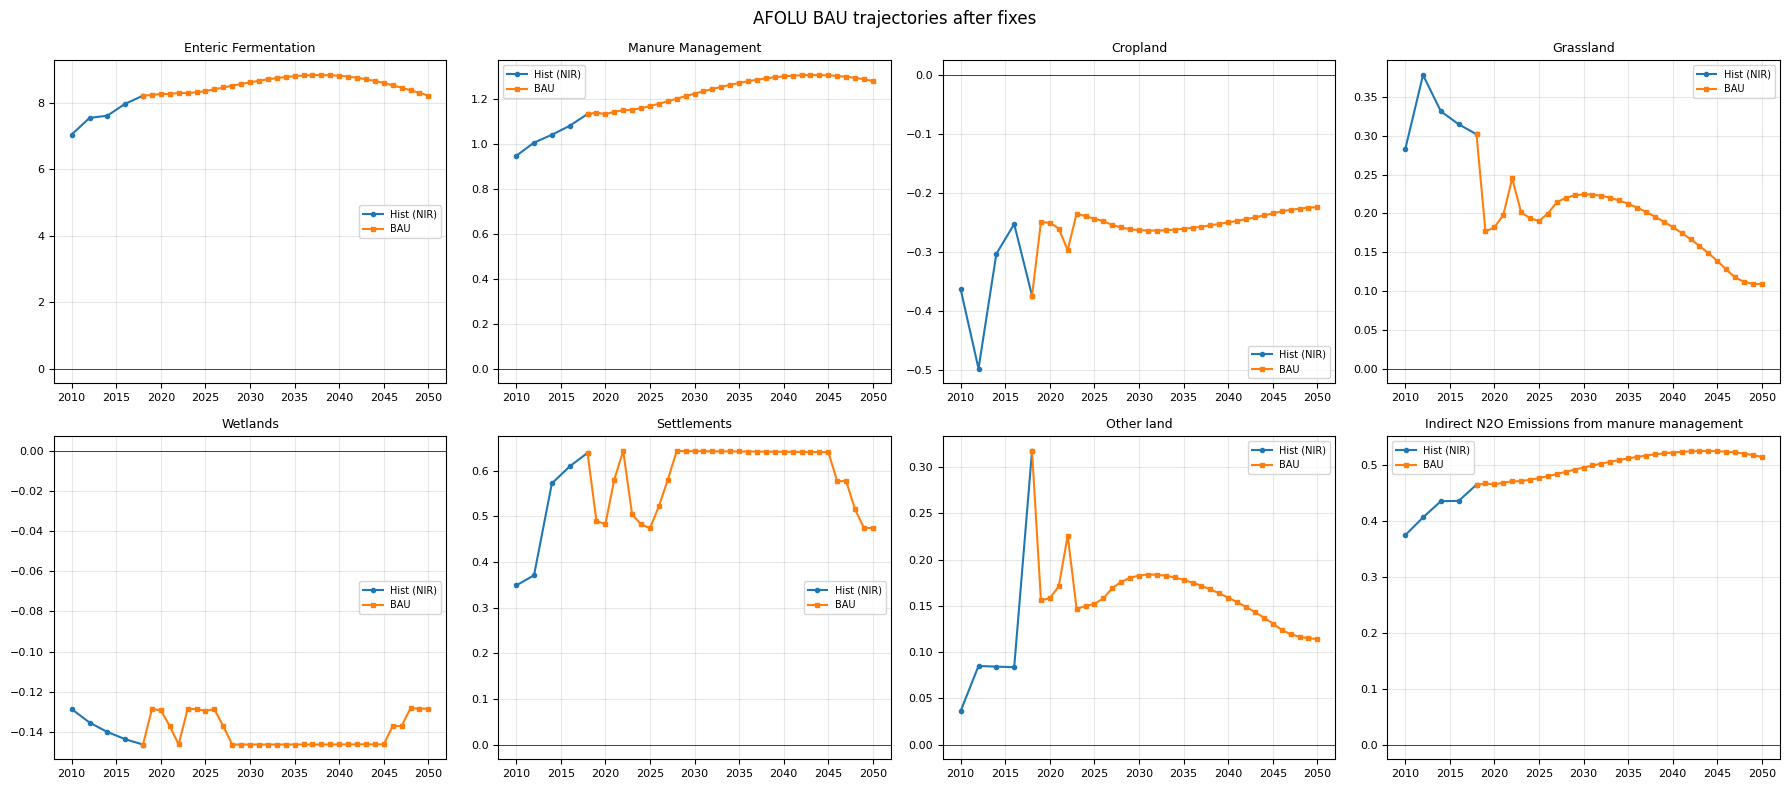

In [14]:
TARGETS = ['3.A.1 - Enteric Fermentation', '3.A.2 - Manure Management',
           '3.B.2 - Cropland', '3.B.3 - Grassland',
           '3.B.4 - Wetlands', '3.B.5 - Settlements',
           '3.B.6 - Other land',
           '3.C.6 - Indirect N2O Emissions from manure management']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, sub in zip(axes.flatten(), TARGETS):
    h = agg[(agg['subsector']==sub) & (agg['strategy']=='Historical')]
    b = agg[(agg['subsector']==sub) & (agg['strategy']=='Strategy TX:BASE')]
    if not h.empty: ax.plot(h['Year'], h['value'], 'o-', label='Hist (NIR)', markersize=3)
    if not b.empty: ax.plot(b['Year'], b['value'], 's-', label='BAU',       markersize=3)
    ax.axhline(0, color='k', linewidth=0.5); ax.grid(alpha=0.3)
    ax.set_title(sub.split(' - ', 1)[-1], fontsize=9)
    ax.tick_params(labelsize=8); ax.legend(fontsize=7)
fig.suptitle('AFOLU BAU trajectories after fixes')
plt.tight_layout(); plt.show()